
--- Running CNN Training Trials ---

Training Trial (Simple)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Trial (Simple) Test Accuracy: 0.9629

Training Trial (Standard)...
Trial (Standard) Test Accuracy: 0.9734

Training Trial (Deep)...
Trial (Deep) Test Accuracy: 0.9776


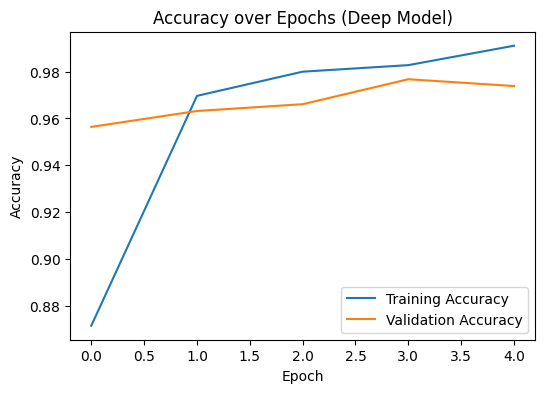

216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


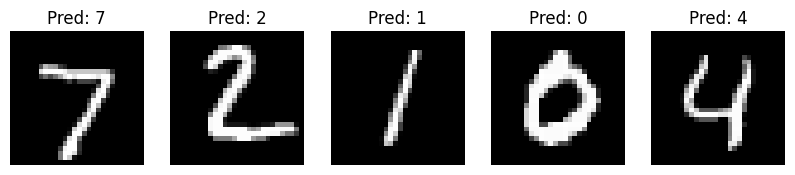

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Load dataset (from uploaded CSV files)
train_data = pd.read_csv('mnist_train.csv')
test_data = pd.read_csv('mnist_test.csv')

# Split features and labels
x_train = train_data.iloc[:, 1:].values
y_train = train_data.iloc[:, 0].values

x_test = test_data.iloc[:, 1:].values
y_test = test_data.iloc[:, 0].values

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print("\n--- Running CNN Training Trials ---")

# Function to build models
def build_model(type="simple"):
    model = keras.Sequential()

    if type == "simple":
        model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
        model.add(layers.MaxPooling2D((2,2)))

    elif type == "standard":
        model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
        model.add(layers.MaxPooling2D((2,2)))
        model.add(layers.Conv2D(64,(3,3),activation='relu'))
        model.add(layers.MaxPooling2D((2,2)))

    elif type == "deep":
        model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
        model.add(layers.Conv2D(32,(3,3),activation='relu'))
        model.add(layers.MaxPooling2D((2,2)))
        model.add(layers.Conv2D(64,(3,3),activation='relu'))
        model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Train models
histories = []

for name in ["simple","standard","deep"]:
    print(f"\nTraining Trial ({name.capitalize()})...")
    model = build_model(name)

    history = model.fit(x_train, y_train,
                        epochs=5,
                        validation_split=0.1,
                        verbose=0)

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Trial ({name.capitalize()}) Test Accuracy: {acc:.4f}")

    histories.append((name, history, model))

# Plot Accuracy Graph (Deep model)
name, history, model = histories[-1]

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title(f'Accuracy over Epochs ({name.capitalize()} Model)')
plt.legend()
plt.show()

# Predictions
predictions = model.predict(x_test)

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {np.argmax(predictions[i])}")
    plt.axis('off')

plt.show()
